# Customer Spending Prediction using Linear Regression

### Import libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Read CSV file on Ecommerse dataset

In [3]:
df = pd.read_csv('Ecommerce.csv')

### Tabel info

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


### basic statistical information

In [5]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


### Trying to find any kind of relationship between customer spent and time on website

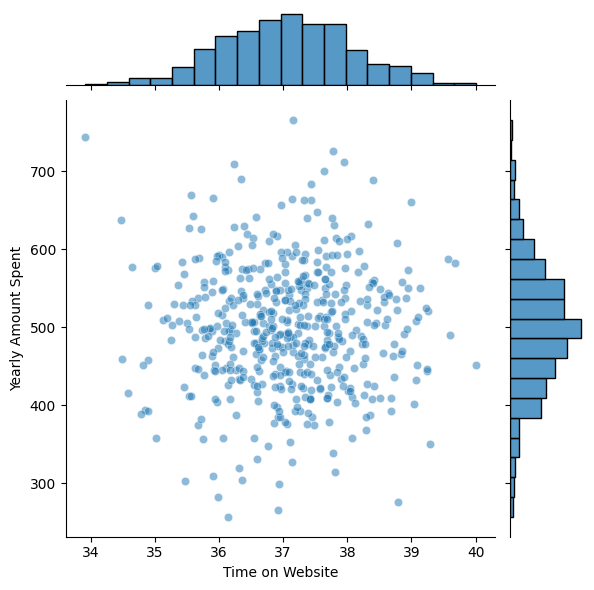

In [6]:
sns.jointplot(x='Time on Website', y = 'Yearly Amount Spent', data = df, alpha=0.5)

### NO real relation could be found, lets relate to Time on App

<Axes: xlabel='Time on App', ylabel='Yearly Amount Spent'>

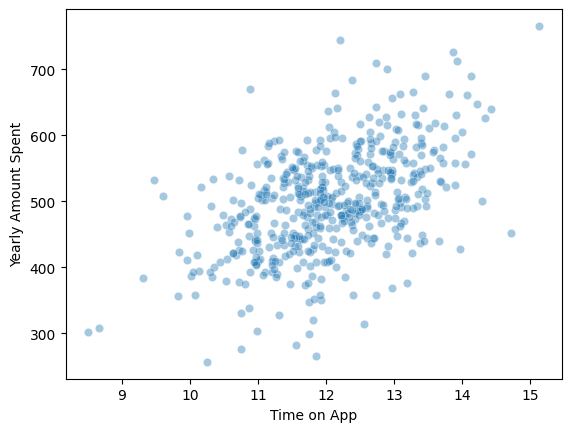

In [7]:
sns.scatterplot(x = 'Time on App', y = 'Yearly Amount Spent', data = df , alpha =0.4)

### Let us try some pairplots 

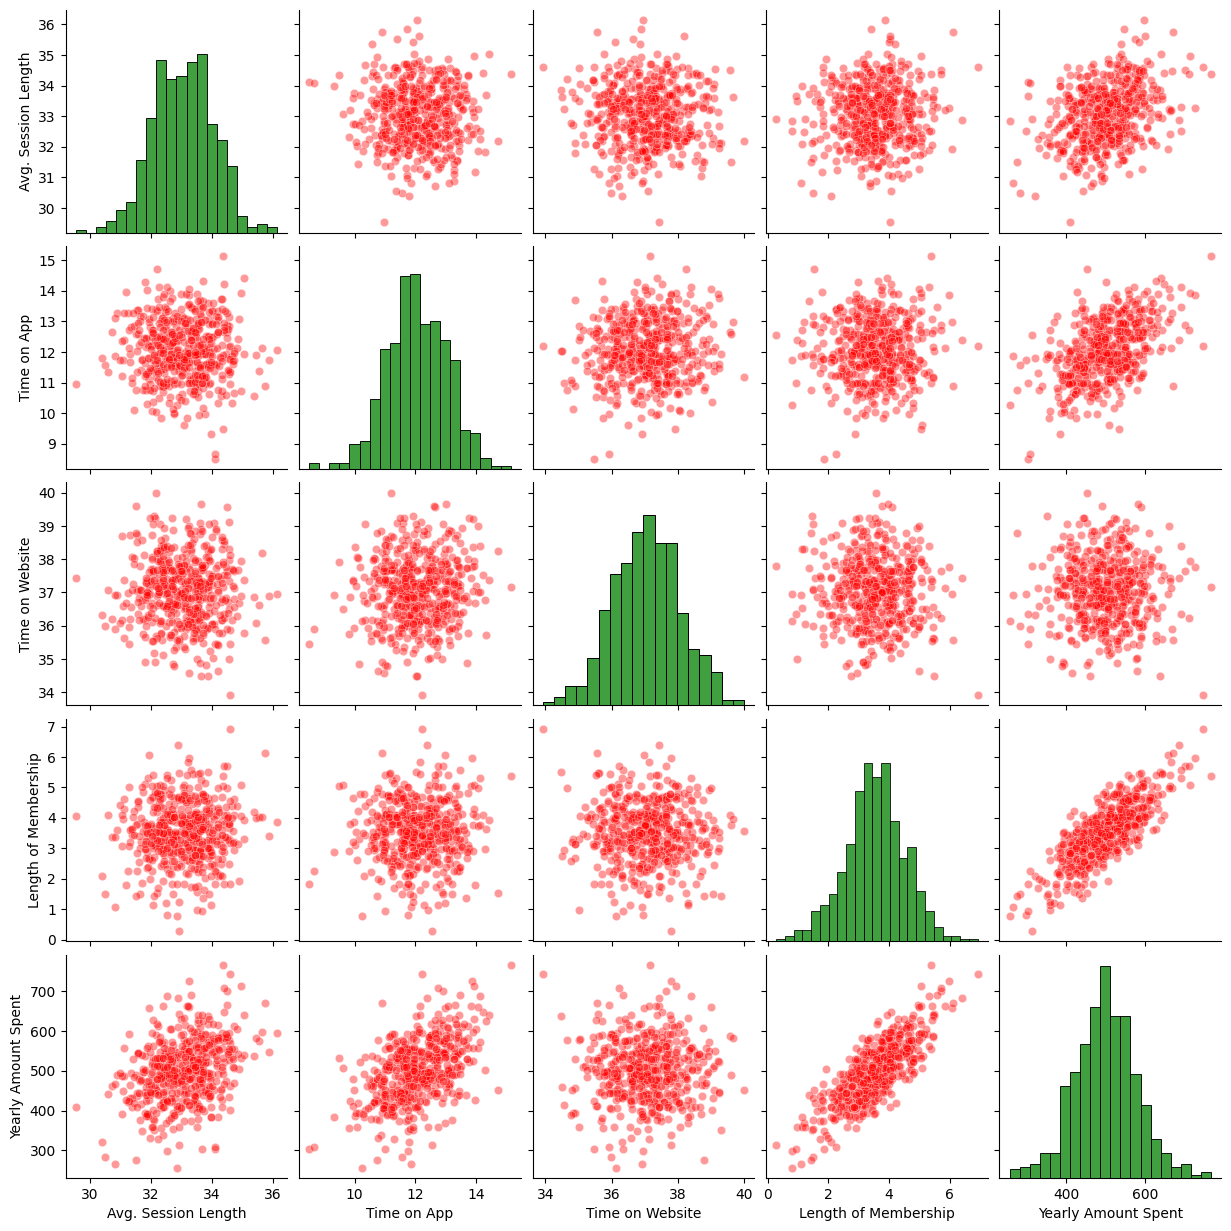

In [8]:
sns.pairplot(df, kind='scatter', plot_kws={'alpha':0.4, 'color':'red'}, diag_kws={'color':'green'})

### Linear model example

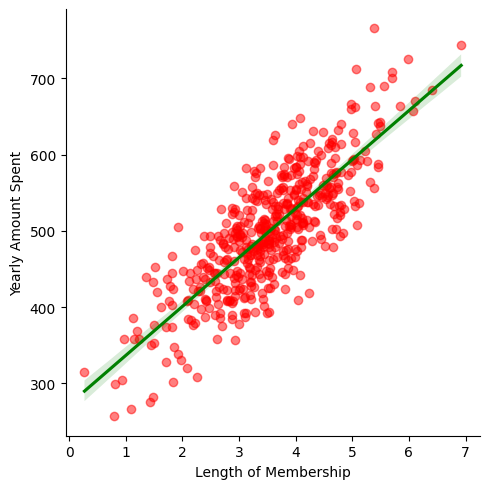

In [19]:
sns.lmplot(x='Length of Membership', y = 'Yearly Amount Spent', data = df, scatter_kws={'alpha':0.5, 'color':'red'}, line_kws={'color':'Green'})

### Split the data into training and testing set

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


### - import sklearn
### - define Dependent and independent variable, we will be predicting yearly amount spent by customers based on data

In [11]:
from sklearn.model_selection import train_test_split
X = df[['Avg. Session Length','Time on App','Time on Website','Length of Membership']]
y = df['Yearly Amount Spent']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### verify the splits

In [12]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 361 to 426
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Avg. Session Length   150 non-null    float64
 1   Time on App           150 non-null    float64
 2   Time on Website       150 non-null    float64
 3   Length of Membership  150 non-null    float64
dtypes: float64(4)
memory usage: 5.9 KB


### Train LM model

In [13]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

#### make prediction on test set X_test

In [14]:
prediction = lm.predict(X_test)

#### check for errors

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math
print(f'mean_absolute_error = {mean_absolute_error(y_test, prediction)}$')
print(f'mean_squared_error  = {mean_squared_error(y_test, prediction)}$')
print(f'RMSE = {math.sqrt(mean_squared_error(y_test, prediction))}$')

mean_absolute_error = 8.426091641432116$
mean_squared_error  = 103.91554136503333$
RMSE = 10.193897260863155$


### check fo normality

<Axes: xlabel='Yearly Amount Spent', ylabel='Count'>

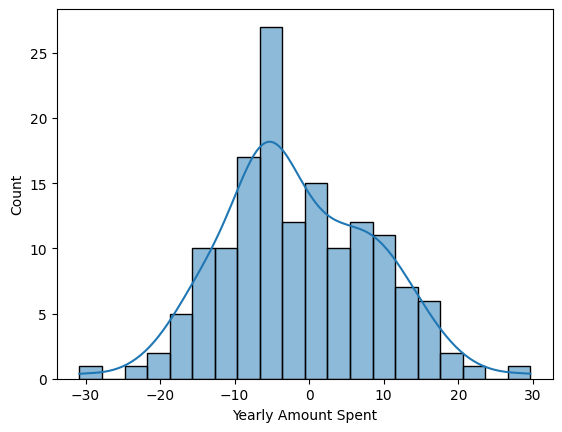

In [16]:
residual = y_test - prediction
sns.histplot(residual, bins= 20, kde=True)

### Q-Q plot to if the distribution is normal

((array([-2.60376328, -2.283875  , -2.1005573 , -1.96875864, -1.86428437,
         -1.77691182, -1.70131573, -1.63435332, -1.57400778, -1.51890417,
         -1.46806125, -1.42075308, -1.37642684, -1.33465133, -1.29508341,
         -1.25744533, -1.22150891, -1.18708433, -1.15401181, -1.12215558,
         -1.0913992 , -1.06164202, -1.03279638, -1.00478546, -0.97754152,
         -0.95100448, -0.92512081, -0.89984257, -0.87512664, -0.85093408,
         -0.8272296 , -0.80398107, -0.78115919, -0.75873709, -0.73669013,
         -0.71499557, -0.69363244, -0.67258128, -0.65182406, -0.63134396,
         -0.61112532, -0.59115349, -0.57141472, -0.55189613, -0.53258558,
         -0.51347162, -0.49454346, -0.47579085, -0.45720409, -0.43877397,
         -0.4204917 , -0.40234892, -0.38433762, -0.36645016, -0.3486792 ,
         -0.33101768, -0.31345882, -0.29599609, -0.27862316, -0.26133393,
         -0.24412247, -0.22698303, -0.20991002, -0.19289797, -0.17594158,
         -0.15903562, -0.142175  , -0.

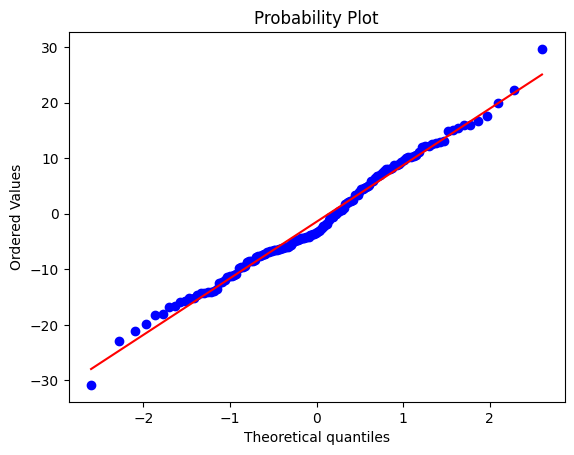

In [17]:
import pylab
import scipy.stats as stats
stats.probplot(residual, dist='norm', plot=pylab)